# PRISMA Strict Keyword Analysis: Hybrid Augmented Intelligence in VRP
This notebook categorizes literature using a binary keyword-matching approach to ensure maximum transparency and consistency for systematic review reporting.

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import warnings
import re

warnings.filterwarnings('ignore')
sns.set(style="whitegrid")

## 1. Data Loading & Robust Deduplication
Ensuring we reach the unique universe of N=626 records.

In [4]:
df = pd.read_csv('scopus_search5.csv')
initial_count = len(df)

df['clean_title'] = df['Title'].str.lower().str.replace(r'[^\w\s]', '', regex=True).str.strip()
df['clean_doi'] = df['DOI'].str.lower().str.strip()

with_doi = df[df['clean_doi'].notna()].drop_duplicates(subset='clean_doi', keep='first')
without_doi = df[df['clean_doi'].isna()]
df_clean = pd.concat([with_doi, without_doi]).drop_duplicates(subset='clean_title', keep='first')

print(f"Initial records: {initial_count} | Unique records: {len(df_clean)}")

Initial records: 627 | Unique records: 626


## 2. Strict Keyword Classification
Using your exhaustive lists to identify the three pillars.

In [ ]:
vrp_terms = ['vehicle routing problem', 'vrp', 'vehicle routing', 'routing problem', 'distribution routing', 'logistics routing']
human_terms = ['human in the loop', 'human-in-the-loop', 'interactive optimization', 'interactive evolutionary', 'interactive search', 'interactive multiobjective', 'decision support', 'decision support system', 'decision-making', 'decision maker', 'decision-maker', 'expert knowledge', 'expert-driven', 'user-guided', 'participatory', 'multi-criteria', 'multicriteria', 'multi-objective decision', 'mcdm', 'ahp', 'topsis', 'electre', 'promethee', 'preference-based', 'preference learning', 'preference elicitation', 'preference modeling', 'preference', 'hitl', 'mca']
heuristic_terms = ['metaheuristic', 'hyper-heuristic', 'hyperheuristic', 'hybrid', 'hybrid algorithm', 'hybrid approach', 'hybrid method', 'hybrid intelligence', 'augmented intelligence', 'machine learning', 'reinforcement learning', 'deep learning', 'learning-based', 'learning guided', 'surrogate model', 'fuzzy', 'fuzzy logic', 'neuro-fuzzy', 'cognitive model', 'knowledge-based', 'data-driven']

def get_flags(row):
    text = (str(row['Title']) + " " + str(row['Author Keywords'])).lower()
    return pd.Series([any(t in text for t in vrp_terms), any(t in text for t in human_terms), any(t in text for t in heuristic_terms)])

df_clean[['has_VRP', 'has_Human', 'has_Heuristic']] = df_clean.apply(get_flags, axis=1)
df_core = df_clean[df_clean['has_Human'] | df_clean['has_Heuristic']].copy()
df_core = df_core[df_core['has_VRP']].copy()

print(f"Analyzed Set: {len(df_core)} | Core Set: {len(df_core)} | Ignored Set: {len(df_clean) - len(df_core)}")

Analyzed Set: 439 | Core Set: 306 | Ignored Set: 187


## 3. Pillar Intersection Analysis (Venn Data)

In [ ]:
df_core['is_gold'] = df_core['has_Human'] & df_core['has_Heuristic']
df_core['is_bridge'] = df_core['is_gold'] & df_core['has_VRP']

print(f"Gold Papers (Human + Heuristic): {df_core['is_gold'].sum()}")
print(f"Bridge Papers (VRP + Human + Heuristic): {df_core['is_bridge'].sum()}")

Gold Papers (Human + Heuristic): 83
Bridge Papers (VRP + Human + Heuristic): 62


## 4. Strict Term Mapping & Heatmap
We identify exactly which specific term from the lists was found in the metadata.

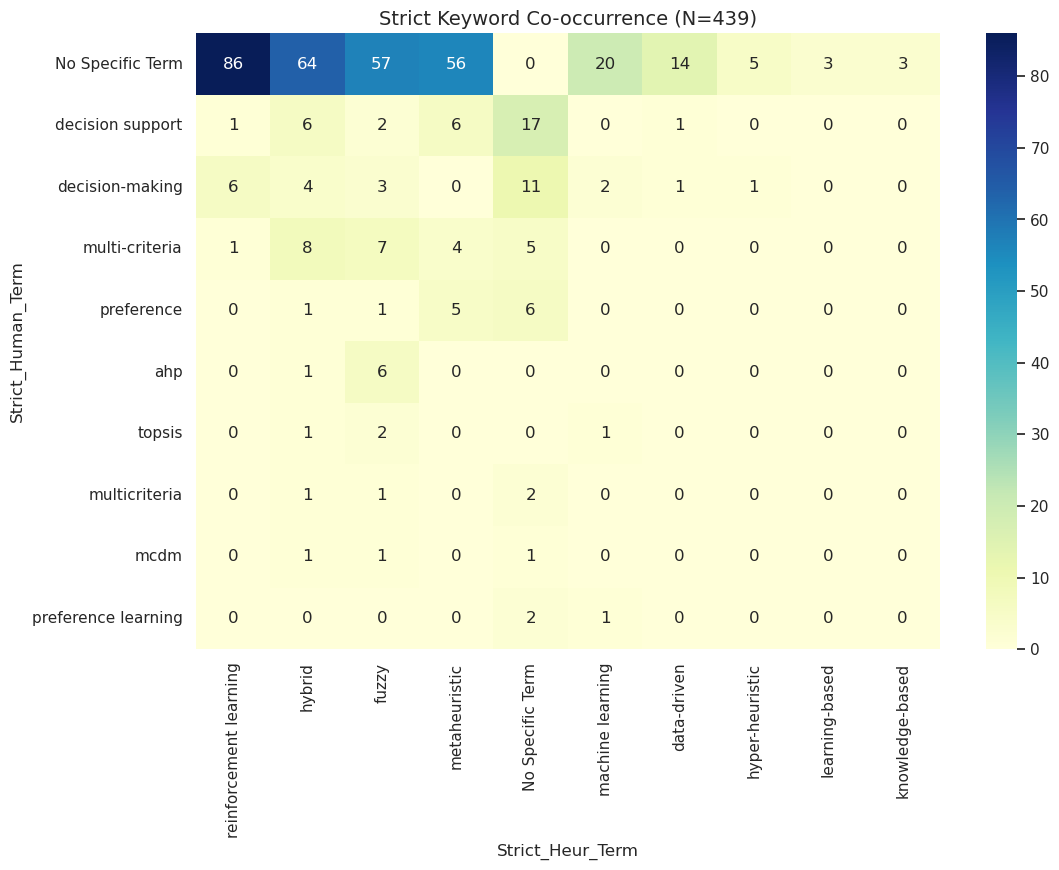

In [ ]:
def find_exact_term(row, terms):
    text = (str(row['Title']) + " " + str(row['Author Keywords'])).lower()
    for t in terms:
        if t in text: return t
    return "No Specific Term"

df_core['Strict_Human_Term'] = df_core.apply(lambda x: find_exact_term(x, human_terms), axis=1)
df_core['Strict_Heur_Term'] = df_core.apply(lambda x: find_exact_term(x, heuristic_terms), axis=1)

# Heatmap of the Top 10 Term Co-occurrences
top_h = df_core['Strict_Human_Term'].value_counts().head(10).index
top_he = df_core['Strict_Heur_Term'].value_counts().head(10).index

plt.figure(figsize=(12, 8))
sns.heatmap(pd.crosstab(df_core['Strict_Human_Term'], df_core['Strict_Heur_Term']).loc[top_h, top_he], annot=True, fmt='d', cmap='YlGnBu')
plt.title("Strict Keyword Co-occurrence (N=439)", fontsize=14)
plt.show()

## 5. Penalty Analysis: Identifying 'No Direct Match'
Finding papers caught by Title broad-matching that lack specific pillar keywords.

In [ ]:
penalized = df_core[df_core['Strict_Human_Term'] == "No Specific Term"]
print(f"Papers caught by broad title match but missing specific Human Keywords: {len(penalized)}")
print("Top keywords in these 'Penalized' papers:")
other_kws = []
for kw in penalized['Author Keywords'].dropna():
    other_kws.extend([k.strip().lower() for k in str(kw).split(';')])
print(Counter(other_kws).most_common(10))

Papers caught by broad title match but missing specific Human Keywords: 311
Top keywords in these 'Penalized' papers:
[('vehicle routing problem', 45), ('deep reinforcement learning', 37), ('reinforcement learning', 33), ('vehicle routing', 24), ('metaheuristic', 18), ('genetic algorithm', 15), ('multi-objective optimization', 15), ('metaheuristics', 15), ('machine learning', 13), ('optimization', 9)]


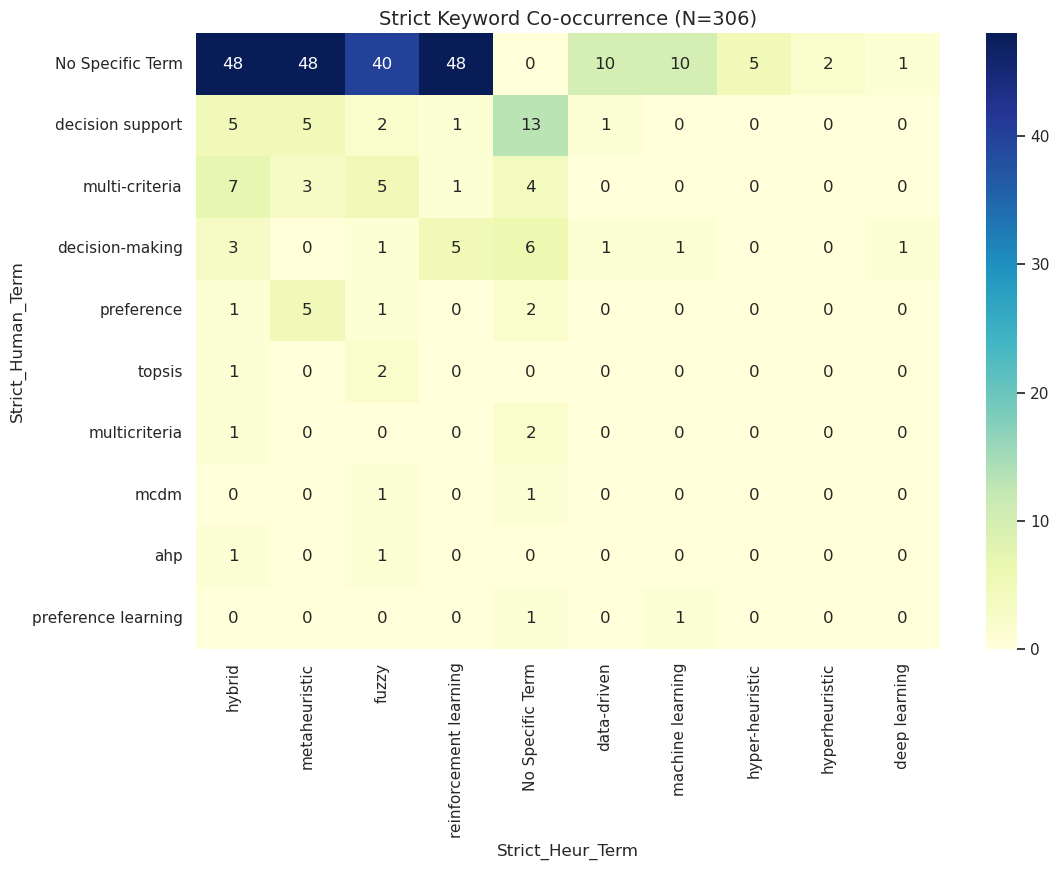

In [16]:
def find_exact_term(row, terms):
    text = (str(row['Title']) + " " + str(row['Author Keywords'])).lower()
    for t in terms:
        if t in text: return t
    return "No Specific Term"

df_core['Strict_Human_Term'] = df_core.apply(lambda x: find_exact_term(x, human_terms), axis=1)
df_core['Strict_Heur_Term'] = df_core.apply(lambda x: find_exact_term(x, heuristic_terms), axis=1)

# Heatmap of the Top 10 Term Co-occurrences
top_h = df_core['Strict_Human_Term'].value_counts().head(10).index
top_he = df_core['Strict_Heur_Term'].value_counts().head(10).index

plt.figure(figsize=(12, 8))
sns.heatmap(pd.crosstab(df_core['Strict_Human_Term'], df_core['Strict_Heur_Term']).loc[top_h, top_he], annot=True, fmt='d', cmap='YlGnBu')
plt.title("Strict Keyword Co-occurrence (N=306)", fontsize=14)
plt.show()